## Unit conversion

earthkit-plots converts data between units automatically at plot time using the
[Pint](https://pint.readthedocs.io/) units library.  No pre-processing of your data is needed:
pass `units=` to any plotting method and the conversion happens transparently - the underlying
array is never modified.

This notebook covers:

- How earthkit-plots uses native units even without passing `units'
- Converting units with the `units` argument
- How styles carry their own units
- Using `fix_x_units` / `fix_y_units` to set units once for all plot calls on a subplot
- A selection of commonly used unit strings

In [1]:
import earthkit.data as ekd
import earthkit.plots as ekp

In [2]:
era5_2t = ekd.from_source("sample", "era5-monthly-mean-2t-199312.grib")

earthkit-data cache: filesystem usage (98%) exceeds limit (95%) set by 'maximum-cache-disk-usage' config option
earthkit-data cache: trying to free 13.8 GiB
earthkit-data cache: could not free 13.8 GiB


### Units-aware by default

Even without passing `units=`, earthkit-plots reads the native units from the
data's metadata and displays them in the legend label and title automatically.
ERA5 2 m temperature is stored in Kelvin, so the plot below shows values in
Kelvin — no configuration required:

In [3]:
chart = ekp.Map(domain="Europe")
chart.contourf(era5_2t)
chart.coastlines()
chart.legend(label="{variable_name} ({units})")
chart.title("{variable_name} – {time:%B %Y}")
chart.show()

### Converting with `units=`

Pass `units=` to convert to a different unit system at plot time.  The legend
and title automatically reflect the converted units:

In [4]:
chart = ekp.Map(domain="Europe")
chart.contourf(era5_2t, units="celsius", style="auto")
chart.coastlines()
chart.legend(label="{variable_name} ({units})")
chart.title("{variable_name} – {time:%B %Y}")
chart.show()

The same data in Fahrenheit requires no other change to the code:

In [5]:
chart = ekp.Map(domain="Europe")
chart.contourf(era5_2t, units="degF", style="auto")
chart.coastlines()
chart.legend(label="{variable_name} ({units})")
chart.title("{variable_name} – {time:%B %Y}")
chart.show()

### Pressure: Pa → hPa

ERA5 mean sea-level pressure is stored in Pascals.  Meteorologists work in
hectopascals (hPa), so `units="hPa"` is the standard conversion to apply.

In [6]:
data = ekd.from_source("sample", "era5-2t-msl-1985122512.grib").to_fieldlist()
pressure = data.sel({"parameter.variable": "msl"})

chart = ekp.Map(domain="North Atlantic")
chart.contour(pressure, units="hPa", style="auto")
chart.coastlines()
chart.legend(label="{variable_name} ({units})")
chart.title("{variable_name} at {time:%H:%M UTC on %d %b %Y}")
chart.show()

### Wind speed: m s⁻¹ → knots

Wind data is conventionally stored in m s⁻¹.  Pint understands a wide variety
of velocity unit strings, so converting to knots, km h⁻¹, or mph is
straightforward.

In [7]:
wind = ekd.from_source("sample", "storm_ophelia_wind_850.grib").to_fieldlist()
u = wind.sel({"parameter.variable": "u"})
v = wind.sel({"parameter.variable": "v"})

chart = ekp.Map()
chart.quiver(u, v, scale=3000, units="knots", cmap="turbo")
chart.coastlines()
chart.legend(label="Wind speed ({units})")
chart.quiverkey(50)
chart.title("10 m wind – {time:%d %B %Y}")
chart.show()

### Styles carry their own units

If a style includes a `units` field, that defines the unit system its colour
levels were designed for.  When you use a style — whether self-defined or a
named style string — earthkit-plots automatically converts your data to those
units.  You do not need to pass `units=` separately.

In [8]:
style = ekp.styles.Style(
    cmap="hot_r",
    # Include units in a style to apply them to input data
    units="celsius",
    levels=range(-20, 21, 2),
    extend="both",
)

chart = ekp.Map(domain="Europe")
chart.contourf(era5_2t, style=style)
chart.coastlines()
chart.legend(label="{variable_name} ({units})")
chart.title("{variable_name} – {time:%B %Y}")
chart.show()

### Setting units once with `fix_x_units` / `fix_y_units`

When you are building a multi-layer plot or a subplot with several fields,
repeating `units=` on every call is verbose.  `fix_x_units` and `fix_y_units`
set a permanent default for a subplot: every subsequent plot call on that
subplot will convert to those units automatically.

This is especially useful for **time series** where the y-axis unit is fixed
for the whole subplot:

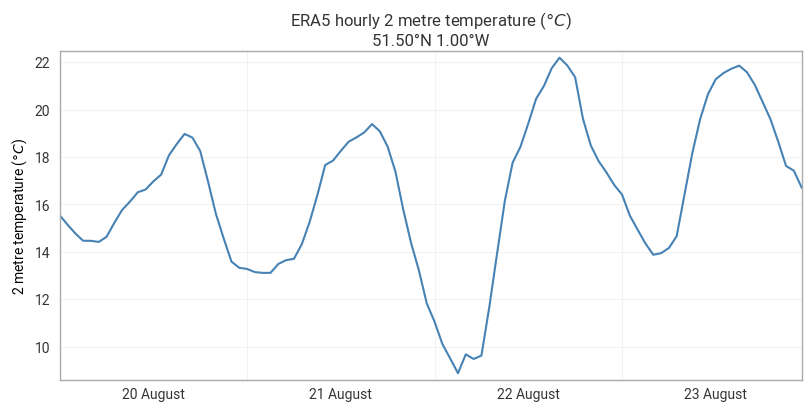

In [9]:
era5_ts = ekd.from_source("sample", "era5-reading-timeseries.nc").to_xarray()

subplot = ekp.TimeSeries()
subplot.fix_y_units("celsius")  # all plot calls on this subplot convert y to °C

subplot.line(era5_ts, color="steelblue")
subplot.title(
    "ERA5 hourly {variable_name} ({units})\n"
    "{latitude:%Lt} {longitude:%Ln}"
)
subplot.xticks(frequency="D", format="%d %B", period=True)
subplot.ylabel()
subplot.show()

### Units supported by earthkit-plots

As mentioned above, unit conversion in earthkit-plots is underpinned by the popular [Pint](https://pint.readthedocs.io/) units library. Over in that project, they maintain a list of the [current set of units supported by Pint](https://github.com/hgrecco/pint/blob/master/pint/default_en.txt), so go and check there for the latest list of supported units.